# Análisis estadístico para detectar patrones y outliers II 🐍🖥️✍️

## Objetivos academicos

- Identificar y manejar datos atípicos en python
- Uso condicionales en python
- Segmentación de datos en python.
- Carga de proyectos a GitHub.


## Práctica guiada: EverPeak Holdings  📊🏙️

---

### **Introducción**

A finales del 2024, SilverBasket Retail Group firmó un acuerdo para incorporar a **EverPeak Holdings** dentro de su portafolio de marcas.

Antes de concretar la adquisición, el equipo de **Estrategia e Integración** debe revisar la calidad y estructura de los datos transaccionales de EverPeak. Este tipo de revisión es un paso regular en procesos de incorporación de empresas, porque garantiza que los futuros análisis de clientes, ventas y márgenes partan de información confiable.

En la primera parte, automatizamos el proceso de limpieza del dataset usando un *DataPipeline*, ahora estamos interesados en determinar si existen datos con un algun comportamiento inusual, segmentar la información para su análisis y por último hacer disponible nuestro análisis en *GitHub*

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style('whitegrid')
sns.set_palette('pastel')

### Carga de datos y exploracion

Ejecutemos el *pipeline* que preparamos en nuestra sesión anterior. El cual:

- Lee los datos desde la fuente 
- Identifica *sentinels* y sustituye por *null*
- Estandariza columnas de texto: 
    - Retira espacios innecesarios
    - Convierte a minúsculas
-Estandariza columnas numéricas:
    - Asegura conversión a numéricos
- Devuelve el conjunto de datos con los cambios realizados

In [7]:
def clean_text_columns(df,text_cols):
    sentinels=['?']
    df_copy=df.copy()
    for col in text_cols:
        df_copy[col]=df_copy[col].str.strip().str.lower().str.replace(sentinels,'Unknown').fillna('Unknown')
    return df_copy

def clean_numeric_columns(df,numeric_cols):
    sentinels=[-999]
    df_copy=df.copy()
    for col in numeric_cols:
        df_copy[col]=pd.to_numeric(df_copy[col],errors='coerce') 
        df_copy[col] = df_copy[col].replace(sentinels,pd.NA)
        df_copy[col] = df_copy[col].fillna(df_copy[col].mean())
    return df_copy

In [8]:
def pipeline_everpeak_retail():
    text_cols=[ 'product_category', 'payment_method', 'city', 'state']
    numeric_cols=[ 'price', 'customer_age']
    df =  pd.read_csv("https://practicum-content.s3.us-west-1.amazonaws.com/datasets/everpeak_retail.csv")
    df= clean_text_columns(df,text_cols)
    df= clean_numeric_columns(df, numeric_cols)
    return df

In [9]:
everpeak_retail=pipeline_everpeak_retail()

C:\Users\roman\AppData\Local\Temp\ipykernel_40524\2225092337.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_copy[col] = df_copy[col].fillna(df_copy[col].mean())


In [6]:
everpeak_retail.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5008 entries, 0 to 5007
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5008 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5008 non-null   int64  
 3   product_category  5008 non-null   object 
 4   price             5008 non-null   int64  
 5   quantity          5008 non-null   int64  
 6   order_value       5008 non-null   int64  
 7   payment_method    5008 non-null   object 
 8   city              5008 non-null   object 
 9   state             5008 non-null   object 
 10  customer_age      5008 non-null   float64
dtypes: float64(1), int64(5), object(5)
memory usage: 430.5+ KB


In [10]:
everpeak_retail.head()

,order_id,order_date,customer_id,product_category,price,quantity,order_value,payment_method,city,state,customer_age
0,1,2024-02-02,2616,Unknown,269,50,13385,Unknown,Unknown,Unknown,66.0
1,2,2024-10-10,1736,Unknown,66,0,660,Unknown,Unknown,Unknown,24.0
2,3,2024-08-27,2543,Unknown,267,0,5073,Unknown,Unknown,Unknown,23.0
3,4,2024-06-09,2252,Unknown,114,125,14290,Unknown,Unknown,Unknown,70.0
4,5,2024-06-07,1583,Unknown,729,16,11754,Unknown,Unknown,Unknown,75.0


In [19]:
everpeak_retail.describe()

,order_id,customer_id,price,quantity,order_value,customer_age
count,5008.000000,5008.000000,5008.000000,5008.000000,5008.000000,5008.000000
mean,2504.500000,1988.362420,756.187500,21.871406,10071.564696,49.122491
std,1445.829404,569.889309,1172.528065,63.303488,12398.053370,17.718554
min,1.000000,1000.000000,12.000000,0.000000,12.000000,18.000000
25%,1252.750000,1495.000000,218.750000,0.000000,3096.250000,34.000000
50%,2504.500000,1988.000000,457.000000,0.000000,10339.500000,49.122491
75%,3756.250000,2475.000000,847.000000,22.000000,13159.250000,64.000000
max,5008.000000,2999.000000,36708.000000,1266.000000,303824.000000,80.000000


### Manejo de datos atípicos

La revisión de los *datos atípicos* en la columna `price` es clave para el negocio porque los valores extremos pueden distorsionar de forma significativa los indicadores que se utilizarán para evaluar el desempeño real de EverPeak, como ingresos, márgenes y elasticidad de precios. Precios anormalmente altos o bajos pueden deberse a errores de captura, problemas de integración de sistemas, devoluciones mal registradas o promociones excepcionales que no representan el comportamiento habitual del negocio. Si estos outliers no se identifican y tratan adecuadamente, pueden llevar a conclusiones erróneas en la valoración de la compañía, en la definición de estrategias comerciales y en la estimación de sinergias post-adquisición, afectando decisiones clave como fijación de precios, segmentación de clientes y proyecciones financieras.

In [16]:
everpeak_retail['price'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
price,5008.0,756.1875,1172.528065,12.0,218.75,457.0,847.0,36708.0


Text(0.5, 0, 'Price')

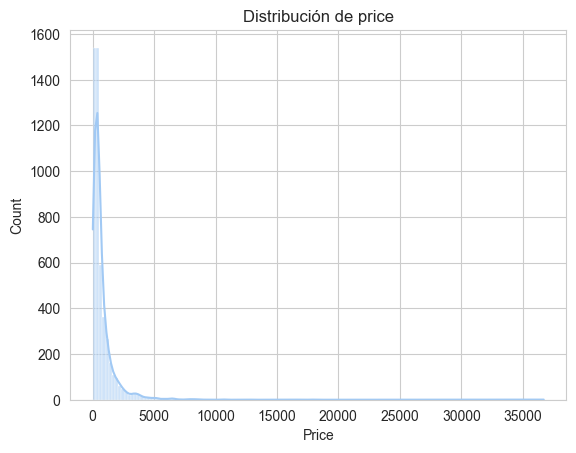

In [43]:
sns.histplot(data=everpeak_retail,x='price',kde=True)
plt.title("Distribución de price")
plt.xlabel('Price')

Text(0.5, 0, 'Price')

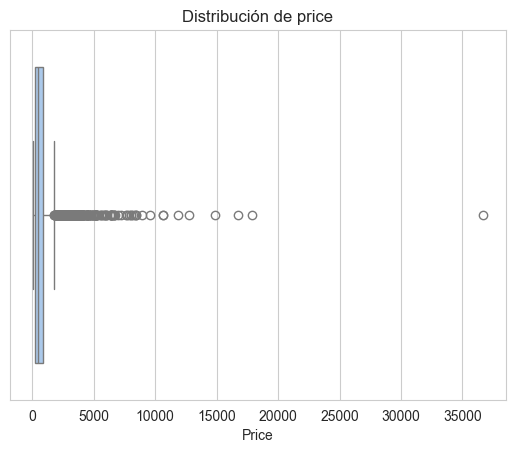

In [44]:
sns.boxplot(data=everpeak_retail,x='price')
plt.title("Distribución de price")
plt.xlabel('Price')

#### Cómo decidir si un dato es atípico

- **Criterio Z (Z-score):** Identifica valores atípicos midiendo cuántas desviaciones estándar se aleja un dato de la media. Un valor se considera atípico cuando su `Z-score` supera un umbral definido (comúnmente $|Z| > 3$), lo que indica que es poco probable dentro de la distribución normal de los datos.

- **Rango Intercuartílico (IQR):** Detecta valores atípicos a partir de la dispersión central de los datos. Se calcula como la diferencia entre el tercer cuartil (**Q3**) y el primer cuartil (**Q1**), y se consideran atípicos los valores que están por debajo de $Q_1 − 1.5·IQR$ o por encima de $Q_3 + 1.5·IQR$, ya que se alejan del comportamiento típico del conjunto.


In [50]:
mean=everpeak_retail['price'].mean()
std=everpeak_retail['price'].std()
q1=everpeak_retail['price'].quantile(0.25)
q3=everpeak_retail['price'].quantile(0.75)

In [56]:
def outlier_z_score(x,mean,std):
    return abs(x-mean)/std > 3

def outlier_iqr(x,q1,q3):
    iqr=q3-q1
    return not((q1-1.5*iqr)<x<(q3+1.5*iqr))


In [57]:
everpeak_retail['outlier_z_score']= everpeak_retail['price'].apply(outlier_z_score,mean=mean,std=std)
everpeak_retail['outlier_iqr']= everpeak_retail['price'].apply(outlier_iqr,q1=q1,q3=q3)

In [58]:
everpeak_retail_outliers=everpeak_retail[['price','outlier_z_score','outlier_iqr']].sort_values(by='price',ascending=True)

In [59]:
everpeak_retail_outliers[everpeak_retail_outliers['outlier_iqr']]

,price,outlier_z_score,outlier_iqr
924,1794,False,True
3821,1798,False,True
3397,1800,False,True
4702,1800,False,True
1863,1800,False,True
...,...,...,...
2215,12729,True,True
2336,14900,True,True
2761,16753,True,True
3296,17872,True,True


#### ¿Qué hacer con un dato atípico?

- **Keep (conservar):** Mantener los valores atípicos cuando representan transacciones reales del negocio, como ventas excepcionales, productos premium o compras corporativas. En el contexto de la revisión de EverPeak, conservarlos permite no perder información relevante sobre segmentos de alto valor que podrían ser estratégicos tras la adquisición.

- **Drop (eliminar):** Eliminar los registros atípicos cuando se identifican como errores claros de captura, duplicados o inconsistencias del sistema (por ejemplo, precios negativos o extremadamente bajos).

- **Winsorize (acotar):** Ajustar los valores extremos a un umbral razonable (por ejemplo, percentiles 1 y 99) sin eliminarlos por completo. En este caso, la winsorización es útil para estabilizar análisis exploratorios y modelos iniciales, manteniendo el volumen de datos mientras se reduce el impacto de precios atípicos en los resultados.


**Drop**

In [60]:
everpeak_retail_drop_outliers=everpeak_retail[everpeak_retail['outlier_iqr']==False]

Text(0.5, 0, 'Price')

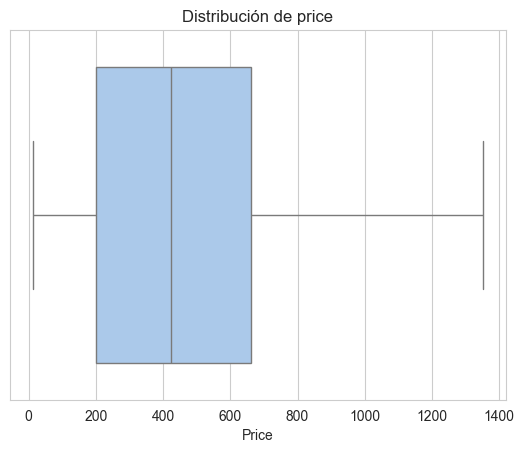

In [64]:
sns.boxplot(data=everpeak_retail_drop_outliers,x='price',showfliers=False)
plt.title("Distribución de price")
plt.xlabel('Price')

**Winsorize**

In [67]:
lower=everpeak_retail['price'].min()
upper=everpeak_retail['price'].quantile(0.99)

In [68]:
everpeak_retail['price_winsorize'] = np.clip(everpeak_retail['price'],lower,upper)

In [69]:
everpeak_retail['price_winsorize'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
price_winsorize,5008.0,725.844421,876.890642,12.0,218.75,457.0,847.0,5147.86


Text(0.5, 0, 'Price')

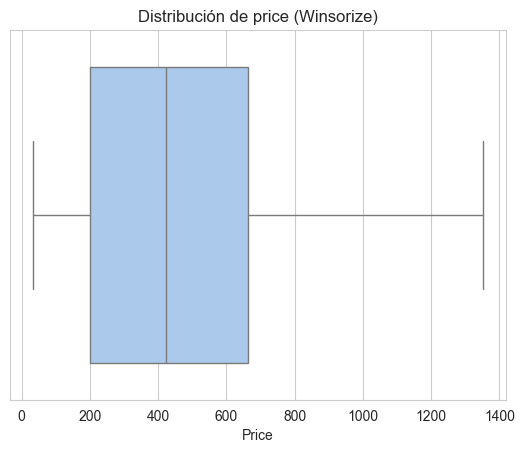

In [70]:
sns.boxplot(data=everpeak_retail_drop_outliers,x='price_winsorize',showfliers=False)
plt.title("Distribución de price (Winsorize)")
plt.xlabel('Price')

### Segmentación de clientes

La segmentación de datos es un paso clave para profundizar el análisis más allá de una visión agregada del negocio. En el contexto de EverPeak, segmentar la información —por ejemplo por categoría de producto, canal de venta o tipo de cliente— permite entender si los comportamientos de precios y la presencia de valores atípicos responden a patrones específicos y legítimos de ciertos segmentos. Este enfoque ayuda al equipo de Estrategia e Integración a diferenciar entre variaciones normales del negocio y posibles problemas de calidad de datos, además de sentar las bases para análisis más precisos de rentabilidad, posicionamiento de marca y oportunidades de crecimiento tras la adquisición.

#### Aprendamos más sobre python 🐍: *Condicionales* ♻️

En programación muchas decisiones dependen de **condiciones** 🤔. Para eso usamos los **condicionales en Python**, que permiten ejecutar código **solo si se cumple una condición**.

🟢 **Condicionales (`if`, `elif`, `else`)**  
Se usan cuando queremos que el programa **tome decisiones** según una lógica booleana (`True` / `False`).

**Estructura general:**
```python
if condicion:
    # código si la condición es verdadera
elif otra_condicion:
    # código si la condición anterior fue falsa
else:
    # código si ninguna condición se cumple
```

**Puntos clave a recordar:**
- Python evalúa las condiciones **de arriba hacia abajo** ⬇️  
- Solo se ejecuta **el primer bloque verdadero**  
- `else` es opcional, pero útil como caso por defecto 🧯  



In [77]:
number=17
if number> 10:
    print(number,' es mayor de 10')

17  es mayor de 10


In [76]:
number=8
if number> 10:
    print(number,' es mayor de 10')
else:
    print(number,' es menor de 10')

8  es menor de 10


In [79]:
number=10
if number> 10:
    print(number,' es mayor de 10')
elif number == 10:
    print(number,' es  10')
else:
    print(number,' es menor de 10')

10  es  10



> 💡 *Los condicionales son como un cruce de caminos: según la condición, el programa toma una ruta distinta.*

Ahora usemos condicionales para segmentar nuestros datos

#### Segmentación por grupo de edad 

Para la revisión inicial de los datos transaccionales de **EverPeak**, uno de los análisis más útiles es la **segmentación por grupo de edad** 👥📊.  

Este ejercicio permite validar si:
- La distribución de clientes es coherente con el tipo de negocio 🧠  
- Existen sesgos o concentraciones inesperadas en ciertos rangos de edad  
- Los patrones de compra cambian según la etapa de vida del cliente  

Además, segmentar por edad facilita futuros análisis de **ventas, ticket promedio y retención**, y sirve como base para estrategias de marketing y pricing después de la integración.

🟢 **Propuesta de segmentación por edad (18 a 80 años)**  

Se propone dividir a los clientes en **4 grupos**, cada uno representando una etapa distinta de consumo:

- **18 – 29 años | Jóvenes adultos** 🎓  
  Clientes en etapas tempranas de su vida laboral. Suelen mostrar tickets más bajos pero mayor frecuencia o adopción digital.

- **30 – 44 años | Adultos jóvenes** 💼  
  Segmento con mayor estabilidad económica. Frecuentemente concentra un alto volumen de ventas y decisiones de compra recurrentes.

- **45 – 59 años | Adultos consolidados** 🏡  
  Clientes con poder adquisitivo sólido. Suelen tener tickets promedio más altos y patrones de compra estables.

- **60 – 80 años | Adultos senior** 🌱  
  Segmento más reducido, pero relevante para analizar lealtad, recurrencia y posibles diferencias en comportamiento de compra.

> 💡 *Esta segmentación permite comparar métricas clave entre grupos y evaluar si los datos de EverPeak reflejan un comportamiento de clientes consistente y accionable.*


In [80]:
def group_by_age(age):
    if age <= 29:
        return "Jóvenes adultos"
    elif  age <= 44:
        return "Adultos jóvenes"
    elif age <= 59:
        return "Adultos consolidados"
    else:
        return "Adultos senior"

In [81]:
everpeak_retail['group_by_age'] = everpeak_retail['customer_age'].apply(group_by_age)

In [83]:
everpeak_retail['group_by_age'].value_counts()

,count
group_by_age,
Adultos senior,1634
Adultos consolidados,1312
Adultos jóvenes,1191
Jóvenes adultos,871


#### Segmentación por grupo de edad y valor de la orden


La gerencia nos ha dado esta propuesta para EverPeak:

<center>
  <img src="https://practicum-content.s3.us-west-1.amazonaws.com/new-markets/Data_refactored_V8/ES/sprint_7/7.3.img1.png" alt="EverPeak Retail Segmentation" style="max-width:50%; height:auto;" width="25%">
</center>

In [85]:
def group_by_age_and_order_value(row):
    age = row['customer_age']
    spend = row['order_value']

    # Manejo de valores nulos/faltantes
    
    if pd.isna(age) or pd.isna(spend):
        return "Error en Datos"

    # Segmentación

    if spend >= 10000 and age >= 55:
        return "Senior VIP"
    elif spend >= 10000 and age < 55:
        return "Junior VIP"
    elif spend >= 5000 and age >= 55:
        return "Sr. Medium Value"
    elif spend >= 5000 and age < 55:
        return "Jr. Medium Value"
    else:
        return "Low Value"


In [86]:
everpeak_retail['segment'] = everpeak_retail.apply(group_by_age_and_order_value,axis=1)

In [88]:
everpeak_retail['segment'].value_counts()

segment
Senior VIP          2005
Low Value           1699
Jr. Medium Value     654
Junior VIP           650
Name: count, dtype: int64

> ¿Qué nos dice esto sobre los clientes de *EverPeak*?

A partir del conteo de clientes por **segmento**, podemos extraer algunas conclusiones iniciales sobre la base de clientes de **EverPeak** 📊🧠

🟢 **Lecturas clave del resultado**

- **Senior VIP (2005 clientes)**  
  Es el segmento más grande. Indica que una parte relevante de la base genera **alto valor** para el negocio, lo cual es positivo para ingresos y estabilidad.

- **Low Value (1699 clientes)**  
  Representa un grupo numeroso de clientes con **bajo aporte económico**. Aquí puede existir oportunidad de **activación, cross-selling o retención**.

- **Jr. Medium Value (654 clientes)** y **Junior VIP (650 clientes)**  
  Ambos segmentos tienen tamaños similares. Esto sugiere una **transición natural** de clientes que podrían escalar a segmentos de mayor valor con la estrategia correcta.

🟢 **Conclusión general**

La distribución muestra una base **heterogénea**, con un núcleo fuerte de clientes de alto valor y una masa importante de clientes de bajo valor.  
Esto es una buena señal para SilverBasket, ya que permite diseñar estrategias diferenciadas por segmento tras la integración.

> 💡 *Un siguiente paso natural sería cruzar estos segmentos con edad, frecuencia de compra o ticket promedio para validar que la segmentación tenga sentido de negocio.*


## 🚀 Para seguir aprendiendo :

---

- 📚 Vuelve a revisar este notebook y trata resolver por tu cuenta  nuevamente
- 💬 Recuerda que en Discord puedes dejar todos tus comentarios y dudas sobre el contenido del sprint en [`Discord`](https://discord.com/channels/1081207584104656986/1420849538196836472).
    - 📝 Si tienes preguntas sobre tu proyecto, usa el canal [`#project`](https://discord.com/channels/1081207584104656986/1420848813186351134) para recibir ayuda y compartir ideas.
    - 🤝 Aprovecha el espacio de `CoLearning` para aclarar tus dudas junto con otros estudiantes e instructores: [Co-Learning](https://discord.com/channels/1081207584104656986/1197953851391746119).
    - En tus preguntas recuerda etiquetar a `@Dataconsulta` y ubica tu pregunta de acuerdo a `Sprint/Capitulo/Seccion`
- 📅 ¿Necesitas ayuda personalizada? Puedes agendar una sesión `1:1` conmigo aquí: [1:1 Roman Castillo](https://scheduler.zoom.us/roman-castillo/1-1-roman-castillo).

- Por último hazme paro y responde la encuesta al final de la sesión, me sirve para poder ayudarte mejor 

¡Sigue practicando y no dudes en pedir apoyo cuando lo necesites! 💪✨